In [1]:
# importing dependencies
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import random
import math
import time
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error
import datetime
import operator
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

### Loading tha Data

In [2]:
confirmed_cases = pd.read_csv("C:\\Users\\DELL\Downloads\\covid-19\\dataset\\time_series_covid19_confirmed_global.csv")

In [3]:
recovered_cases = pd.read_csv("C:\\Users\\DELL\Downloads\\covid-19\\dataset\\time_series_covid19_deaths_global.csv")

In [4]:
death_cases = pd.read_csv("C:\\Users\\DELL\Downloads\\covid-19\\dataset\\time_series_covid19_recovered_global.csv")

### Concating Datasets

In [5]:
Total_cases = pd. concat([confirmed_cases,recovered_cases,death_cases], ignore_index = True)

In [6]:
Total_cases.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


### EDA(Exploratory data anlysis)

In [7]:
Total_cases.shape

(785, 248)

In [8]:
columns = Total_cases.columns
columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '9/12/20', '9/13/20', '9/14/20', '9/15/20', '9/16/20', '9/17/20',
       '9/18/20', '9/19/20', '9/20/20', '9/21/20'],
      dtype='object', length=248)

In [9]:
print(type(Total_cases))

<class 'pandas.core.frame.DataFrame'>


### Handling missing values

In [10]:
Total_cases.drop(['Lat', 'Long'], axis=1, inplace=True)

In [11]:
Total_cases.head()

,Province/State,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,0,0,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,0,0,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,0,0,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,0,0,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,0,0,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


In [12]:
Total_cases_aggregated = Total_cases.groupby("Country/Region").sum()

In [13]:
Total_cases_aggregated.head()

,Province/State,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,71295,71774,72270,72339,72794,72813,72896,72932,73061,73094
Albania,0,0,0,0,0,0,0,0,0,0,...,18009,18256,18473,18680,18892,19083,19257,19472,19687,19894
Algeria,0,0,0,0,0,0,0,0,0,0,...,83487,83903,84320,84751,85128,85523,85890,86211,86545,86882
Andorra,0,0,0,0,0,0,0,0,0,0,...,2340,2340,2436,2436,2590,2590,2781,2781,2781,2933
Angola,0,0,0,0,0,0,0,0,0,0,...,4756,4823,4899,5040,5219,5338,5438,5493,5588,5720


In [14]:
most_affected=Total_cases_aggregated.sort_values(by = columns[-1],ascending = False)
most_affected=most_affected.head(10)

### Data Visualisation

In [15]:
import seaborn as sns

Text(0.5, 1.0, 'Total confirmed cases so far')

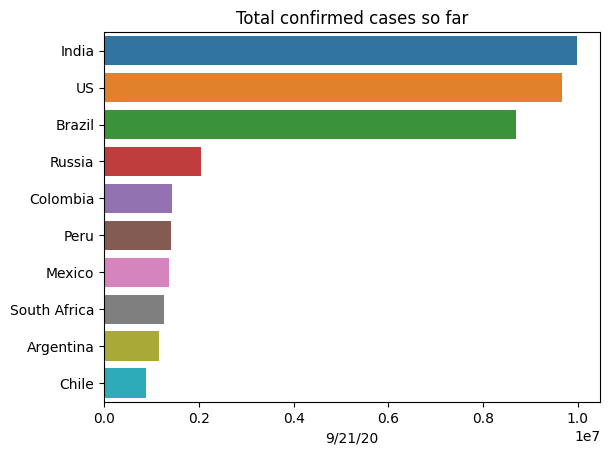

In [16]:
ax = sns.barplot(x=most_affected[most_affected.columns[-1]], y=most_affected.index.values)
ax.set_title("Total confirmed cases so far")


In [17]:
Total_cases_aggregated.shape


(188, 245)

In [18]:
Total_cases_aggregated.loc["India"]


Province/State          0
1/22/20                 0
1/23/20                 0
1/24/20                 0
1/25/20                 0
                   ...   
9/17/20           9411600
9/18/20           9602064
9/19/20           9790414
9/20/20           9971861
9/21/20           9971861
Name: India, Length: 245, dtype: object

### Total cases aggregated in different regions or countries

<Axes: >

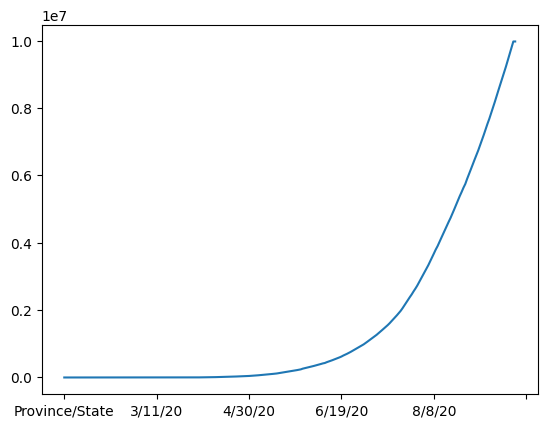

In [19]:

Total_cases_aggregated.loc['India'].plot()

<Axes: >

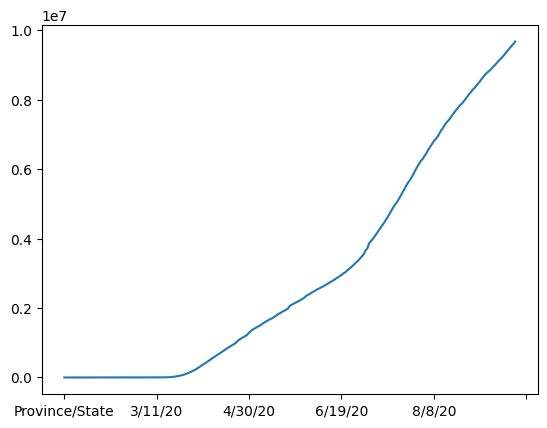

In [20]:
Total_cases_aggregated.loc['US'].plot()

<Axes: >

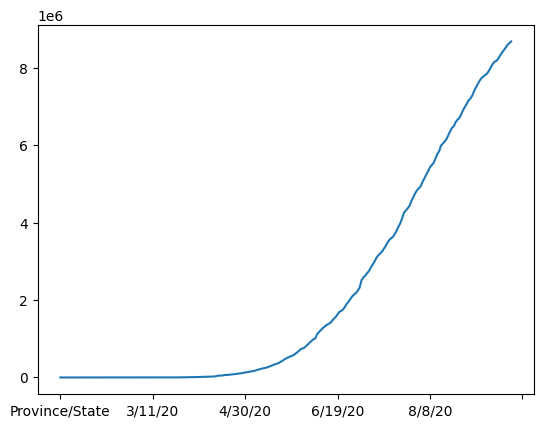

In [21]:
Total_cases_aggregated.loc['Brazil'].plot()

<Axes: >

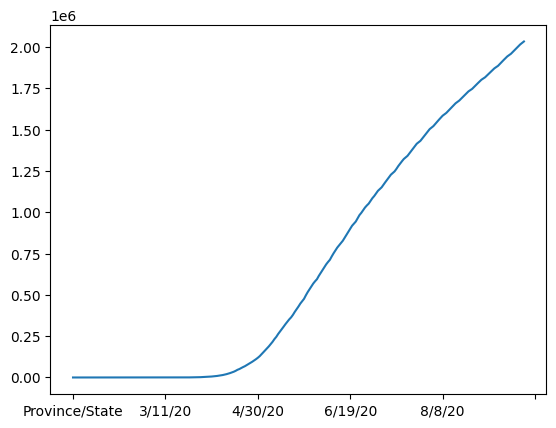

In [22]:
Total_cases_aggregated.loc['Russia'].plot()

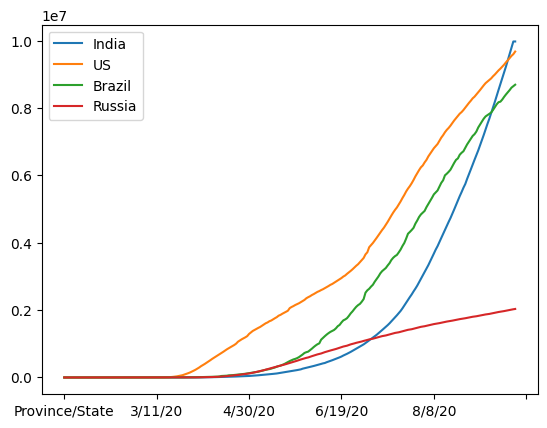

In [23]:
Total_cases_aggregated.loc['India'].plot()
Total_cases_aggregated.loc['US'].plot()
Total_cases_aggregated.loc['Brazil'].plot()
Total_cases_aggregated.loc['Russia'].plot()
plt.legend()

<Axes: >

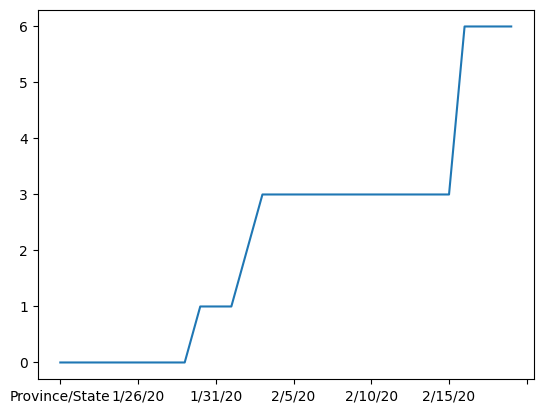

In [24]:
Total_cases_aggregated.loc['India'][:30].plot()

<Axes: >

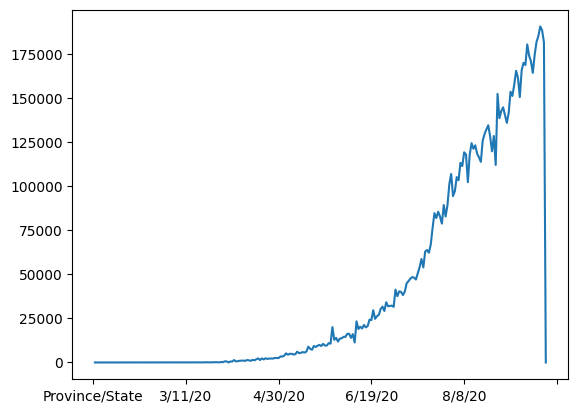

In [25]:
Total_cases_aggregated.loc["India"].diff().plot()

In [26]:
Total_cases_aggregated.loc["India"].diff().max()

190464

In [27]:
Total_cases_aggregated.loc["US"].diff().max

<bound method Series.max of Province/State      NaN
1/22/20               1
1/23/20               0
1/24/20               1
1/25/20               0
                  ...  
9/17/20           59991
9/18/20           66590
9/19/20           65879
9/20/20           50147
9/21/20           77704
Name: US, Length: 245, dtype: object>

In [28]:
Total_cases_aggregated = Total_cases_aggregated.apply(pd.to_numeric, errors='coerce')

In [29]:
countries = list(Total_cases_aggregated.index)
max_infection_rates = []
for c in countries :
    max_infection_rates.append(Total_cases_aggregated.loc[c].diff().max())
max_infection_rates

[2299.0,
 326.0,
 1373.0,
 191.0,
 443.0,
 39.0,
 80430.0,
 1586.0,
 2785.0,
 1443.0,
 1150.0,
 428.0,
 1513.0,
 21448.0,
 14.0,
 2131.0,
 2976.0,
 150.0,
 586.0,
 34.0,
 4152.0,
 1628.0,
 360.0,
 189407.0,
 26.0,
 995.0,
 201.0,
 857.0,
 167.0,
 593.0,
 33.0,
 3795.0,
 24272.0,
 416.0,
 100.0,
 44830.0,
 16523.0,
 39628.0,
 70.0,
 2408.0,
 708.0,
 3504.0,
 669.0,
 670.0,
 166.0,
 205.0,
 3576.0,
 1186.0,
 286.0,
 380.0,
 5.0,
 3447.0,
 23971.0,
 2253.0,
 611.0,
 3122.0,
 68.0,
 538.0,
 353.0,
 3893.0,
 5.0,
 1535.0,
 30029.0,
 884.0,
 349.0,
 239.0,
 16185.0,
 6055.0,
 813.0,
 6.0,
 22615.0,
 557.0,
 471.0,
 176.0,
 552.0,
 10.0,
 2551.0,
 1087.0,
 160.0,
 190464.0,
 8093.0,
 8444.0,
 8731.0,
 9587.0,
 12489.0,
 9827.0,
 260.0,
 5187.0,
 951.0,
 19258.0,
 1663.0,
 1540.0,
 1487.0,
 2275.0,
 19115.0,
 4.0,
 167.0,
 1624.0,
 241.0,
 287.0,
 10036.0,
 21.0,
 115.0,
 2311.0,
 9.0,
 1082.0,
 465.0,
 377.0,
 393.0,
 100.0,
 128.0,
 374.0,
 73.0,
 18092.0,
 2397.0,
 19.0,
 56.0,
 855.0,
 491

In [30]:
Total_cases_aggregated["max_infection_rates"] = max_infection_rates

In [31]:
Total_cases_aggregated.head()

,Province/State,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20,max_infection_rates
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0,0,0,0,0,0,0,0,0,0,...,71774,72270,72339,72794,72813,72896,72932,73061,73094,2299.0
Albania,0.0,0,0,0,0,0,0,0,0,0,...,18256,18473,18680,18892,19083,19257,19472,19687,19894,326.0
Algeria,0.0,0,0,0,0,0,0,0,0,0,...,83903,84320,84751,85128,85523,85890,86211,86545,86882,1373.0
Andorra,0.0,0,0,0,0,0,0,0,0,0,...,2340,2436,2436,2590,2590,2781,2781,2781,2933,191.0
Angola,0.0,0,0,0,0,0,0,0,0,0,...,4823,4899,5040,5219,5338,5438,5493,5588,5720,443.0


In [32]:
Total_data = pd.DataFrame(Total_cases_aggregated["max_infection_rates"])
Total_data.head()

,max_infection_rates
Country/Region,
Afghanistan,2299.0
Albania,326.0
Algeria,1373.0
Andorra,191.0
Angola,443.0


In [33]:
Total_data.columns=Total_data.columns.str.strip()

In [34]:
Total_data.sort_values(by ='max_infection_rates', inplace=True, ascending = False)

In [35]:
top_10=Total_data.head(10)

Text(0.5, 1.0, 'Countries with biggest infection rates')

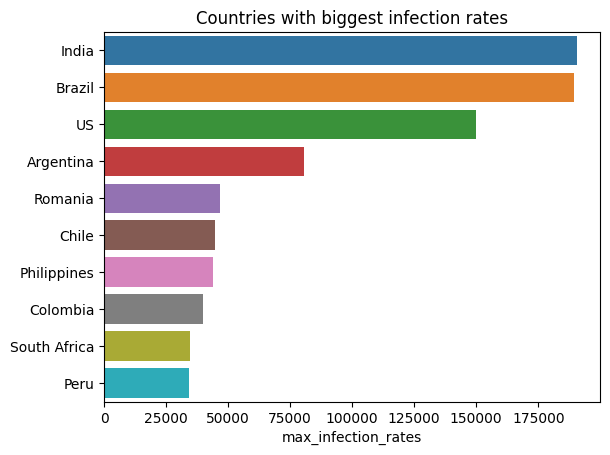

In [36]:
ax = sns.barplot(x=top_10['max_infection_rates'], y=top_10.index.values)
ax.set_title("Countries with biggest infection rates")

In [37]:
Total = Total_cases

### Model Training and Evaluation

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


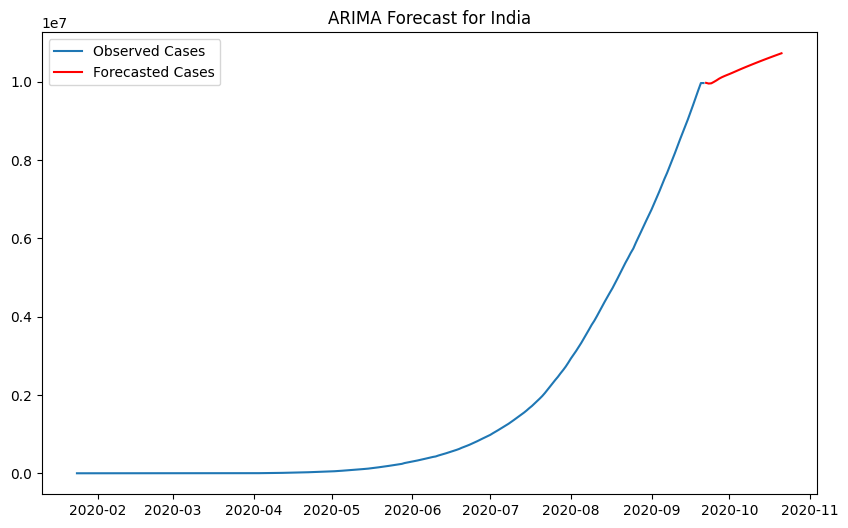

In [39]:
# Filter data for a specific country
country = 'India'  # Change to the desired country
Total = Total_cases[Total_cases['Country/Region'] == country].iloc[:, 4:].sum()

# Transform data into a time-series
Total.index = pd.to_datetime(Total_cases.columns[4:], format='%m/%d/%y')
time_series = pd.DataFrame(Total, columns=['Cases'])

# Fit an ARIMA model
model = ARIMA(time_series['Cases'], order=(5, 1, 0))  # Adjust order as needed
model_fit = model.fit()

# Forecast for the next 30 days
forecast = model_fit.forecast(steps=30)

# Create a date range for the forecast
forecast_dates = pd.date_range(time_series.index[-1] + pd.Timedelta(days=1), periods=30)

# Plot the observed data and forecast
plt.figure(figsize=(10, 6))
plt.plot(time_series.index, time_series['Cases'], label='Observed Cases')
plt.plot(forecast_dates, forecast, label='Forecasted Cases', color='red')
plt.legend()
plt.title(f"ARIMA Forecast for {country}")
plt.show()


C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Mean Squared Error (MSE): 1096766174709.6885
Root Mean Squared Error (RMSE): 1047266.0477212504
R-squared (R2): 0.7320187728592182


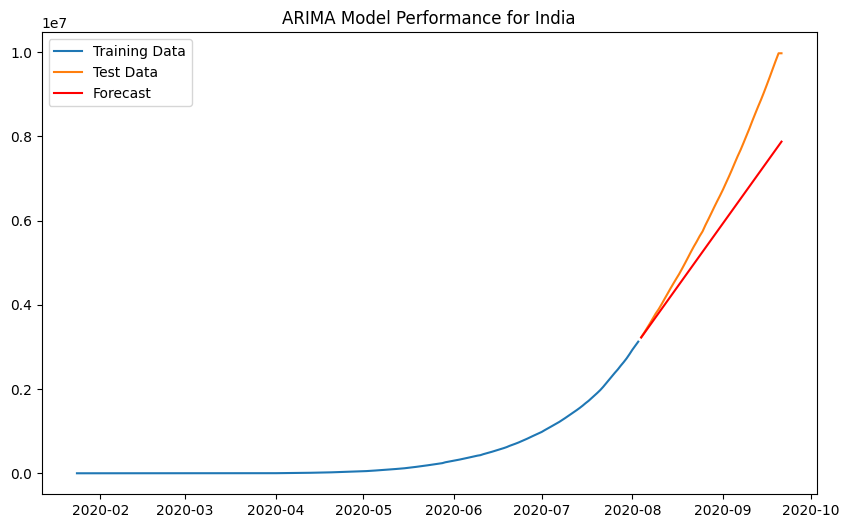

In [40]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split the data into train and test
train_size = int(len(time_series) * 0.8)  # 80% train, 20% test
train, test = time_series[:train_size], time_series[train_size:]

# Fit the ARIMA model on the training data
model = ARIMA(train['Cases'], order=(5, 1, 0))  # Adjust order as needed
model_fit = model.fit()

# Forecast for the test period
forecast_steps = len(test)
forecast = model_fit.forecast(steps=forecast_steps)

# Calculate metrics
mse = mean_squared_error(test['Cases'], forecast)
rmse = np.sqrt(mse)
r2 = r2_score(test['Cases'], forecast)

# Print metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

# Plot the observed data, train, test, and forecast
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Cases'], label='Training Data')
plt.plot(test.index, test['Cases'], label='Test Data')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title(f"ARIMA Model Performance for {country}")
plt.show()


C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda4\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Mean Squared Error (MSE): 158413460440.29355
Root Mean Squared Error (RMSE): 398011.8847977954
R-squared (R2): 0.9612936334988226


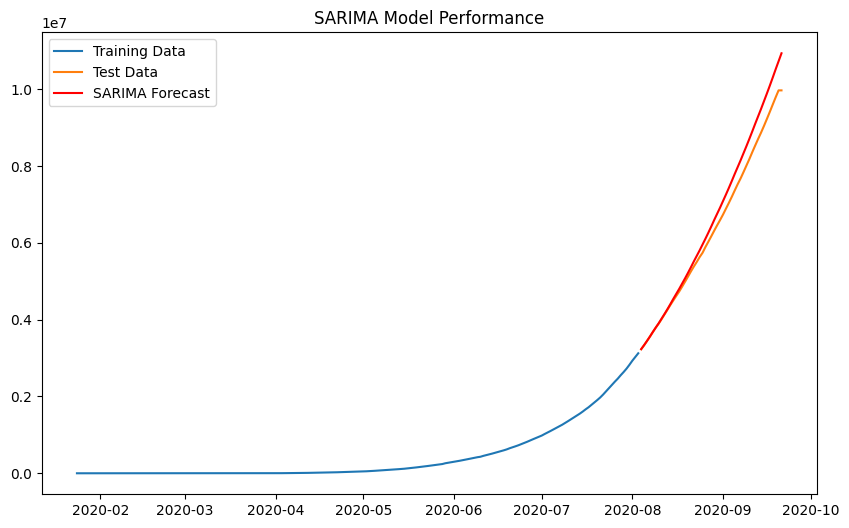

In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define seasonal period (e.g., 7 for weekly seasonality; adjust as needed)
seasonal_period = 7

# Split the data into train and test
train_size = int(len(time_series) * 0.8)  # 80% train, 20% test
train, test = time_series[:train_size], time_series[train_size:]

# Fit SARIMA model with seasonal components
sarima_model = SARIMAX(train['Cases'], order=(5, 1, 0), seasonal_order=(1, 1, 1, seasonal_period))
sarima_fit = sarima_model.fit(disp=False)

# Forecast for the test period
forecast = sarima_fit.forecast(steps=len(test))

# Calculate evaluation metrics
mse_sarima = mean_squared_error(test['Cases'], forecast)
rmse_sarima = np.sqrt(mse_sarima)
r2_sarima = r2_score(test['Cases'], forecast)

# Print metrics
print(f"Mean Squared Error (MSE): {mse_sarima}")
print(f"Root Mean Squared Error (RMSE): {rmse_sarima}")
print(f"R-squared (R2): {r2_sarima}")

# Plot the observed vs forecasted data
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Cases'], label='Training Data')
plt.plot(test.index, test['Cases'], label='Test Data')
plt.plot(test.index, forecast, label='SARIMA Forecast', color='red')
plt.legend()
plt.title("SARIMA Model Performance")
plt.show()


In [42]:
from sklearn.metrics import f1_score

# Define a threshold for classification
threshold = 50  # Example threshold; adjust based on your dataset

# Convert true values and predictions to binary classes
test_binary = (test['Cases'] > threshold).astype(int)
forecast_binary = (forecast > threshold).astype(int)

# Calculate F1 Score
f1 = f1_score(test_binary, forecast_binary)

print(f"F1 Score: {f1}")


F1 Score: 1.0


### Suggestions for governm

1. Strengthening Healthcare Infrastructure
Increase Capacity:
Expand hospital beds and intensive care units (ICUs) in regions forecasted to experience a surge in cases.

Establish temporary healthcare facilities to handle overflow, especially in urban areas with higher predicted cases.

Medical Supplies:
Stockpile essential medical supplies, including ventilators, oxygen cylinders, and personal protective equipment (PPE) for healthcare workers.

2. Enhance Testing and Surveillance
Testing:
Ramp up diagnostic testing in regions with rising case trajectories.
Deploy mobile testing units to underserved or rural areas.

Contact Tracing:
Strengthen contact tracing mechanisms to quickly isolate potential outbreaks.
Integrate data-driven systems for monitoring hotspots based on forecasted trends.

3. Public Health Campaigns
Awareness:
Launch campaigns to promote vaccination, mask-wearing, and social distancing in areas forecasted to have higher case counts.

Behavioral Guidance:
Provide clear guidelines on hygiene practices and the importance of reducing gatherings.
Digital Outreach:
Use mobile alerts and social media to update citizens about localized risks and prevention measures.

4. Vaccine Distribution
Targeted Vaccination:
Prioritize vaccine distribution to regions with higher forecasted cases.
Focus on high-risk groups such as the elderly, frontline workers, and individuals with comorbidities.

Cold Chain Management:
Strengthen cold storage and transportation for vaccines to ensure smooth delivery.

5. Economic Support Measures
Support for Quarantined Areas:
Provide financial assistance and food security programs to individuals in lockdown areas.

Small Businesses:
Offer subsidies or loans to small businesses affected by reduced activity due to restrictions.

6. Emergency Preparedness
Workforce:
Train additional healthcare workers and volunteers to manage increased patient loads.

7.Emergency Protocols:
Ensure quick mobilization of resources and clear escalation protocols in case of an unexpected spike.

8. Data-Driven Policies Adaptive Restrictions:
Use real-time forecasts to implement localized lockdowns or travel restrictions.

9.Dynamic Resource Allocation:
Allocate healthcare resources dynamically based on forecasted trends, reducing inefficiencies.



### Report

1.We faced many challenges upon this dataset ,for example here we got 3 datasets for this project and main thing is we are not familiar with
these types of different datasets for single project ,we are confused wheather we have to concat or do separate analysis for each dataset , 
after spending so much time we got to know that we can concat the datasets or we can do separate analysis also so decided to concat and even 
got errors during the datatime forecasting we managed to elimate them.


### Model comparison